# Visualise Coarse-Grained results of the Janssen pile example

### Import relevant packages

In [9]:
from pysammos.data_write.h5.writer import H5XarrayManager

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [11]:
# font
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams.update({'font.size': 14})

### Initialise data reader manager

In [12]:
manager = H5XarrayManager("./PysammosCG/CG_Lucy_Polydisperse.h5")
janssen_CG = manager.h5_to_xarray()

Processing key: coordination_number
Processing key: density_mixture
Processing key: fabric_tensor
Processing key: frictional_coefficient_01_Pxy
Processing key: frictional_coefficient_01_Pxyz
Processing key: frictional_coefficient_01_Py
Processing key: frictional_coefficient_Dxy_Pxy
Processing key: frictional_coefficient_Dxy_Pxyz
Processing key: frictional_coefficient_Dxy_Py
Processing key: frictional_coefficient_Dxyz_Pxy
Processing key: frictional_coefficient_Dxyz_Pxyz
Processing key: frictional_coefficient_Dxyz_Py
Processing key: granular_temperature_x
Processing key: granular_temperature_xyz
Processing key: granular_temperature_y
Processing key: granular_temperature_z
Processing key: phases
Processing key: positions
Processing key: pressure_x
Processing key: pressure_xy
Processing key: pressure_xyz
Processing key: pressure_y
Processing key: pressure_z
Processing key: time
Processing key: total_stress_tensor_xy_dev
Processing key: total_stress_tensor_xy_dev_mag
Processing key: total_s

In [13]:
janssen_CG.phase

<xarray.DataArray 'phase' (phase: 5)> Size: 700B
array(['Bulk', 'Phase_[4.2375745e-03 2.5000000e+03]',
       'Phase_[5.6632482e-03 2.5000000e+03]',
       'Phase_[5.108148e-03 2.500000e+03]',
       'Phase_[4.6750368e-03 2.5000000e+03]'], dtype='<U35')
Coordinates:
  * phase    (phase) <U35 700B 'Bulk' ... 'Phase_[4.6750368e-03 2.5000000e+03]'

In [14]:
np.asarray(janssen_CG.pressure_y.values[:, :, :]).shape
vv = np.asarray(janssen_CG.pressure_y.values[:, :, :]).mean(axis=0)
vv.shape

(3444, 5)

### Plotting the pressure

In [15]:
def vertical_profile(x, y, var, x_center, tolerance, n_bins=30):
    # Select points near the vertical slice
    mask = np.abs(x - x_center) < tolerance
    y_sel = y[mask]
    var_sel = var[mask]

    # Define vertical bins
    y_bins = np.linspace(y_sel.min(), y_sel.max(), n_bins + 1)
    bin_idx = np.digitize(y_sel, y_bins)

    # Average per bin
    y_centers = []
    var_means = []

    for i in range(1, n_bins + 1):
        m = bin_idx == i
        if np.any(m):
            y_centers.append(y_sel[m].mean())
            var_means.append(var_sel[m].mean())

    return np.array(var_means), np.array(y_centers)


/tmp/ipykernel_3779150/476306613.py:53: RuntimeWarning: divide by zero encountered in log10
  c=np.log10(var_bulk),
/tmp/ipykernel_3779150/476306613.py:53: RuntimeWarning: invalid value encountered in log10
  c=np.log10(var_bulk),


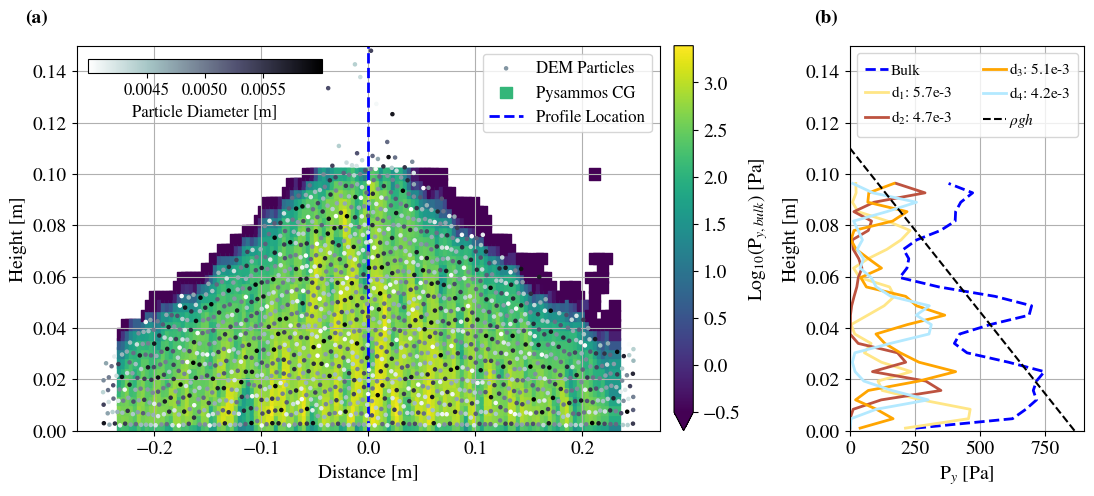

In [16]:
# Create figure
fig, ax = plt.subplots(
    1, 2, figsize=(13, 5),
    gridspec_kw={'width_ratios': [3, 1]}
)

# ---------------------------
# 1) DEM particles
# ---------------------------
janssen_DEM = pv.read('../data_examples/jannsen_pile/DEM_data/DES_FB1_0614.vtp')

janssen_particles = janssen_DEM.points
x_particle = janssen_particles[:, 0]
y_particle = janssen_particles[:, 1]

scatter_particles = ax[0].scatter(
    x_particle, y_particle,
    s=5,
    c=janssen_DEM['Diameter'],
    cmap='bone_r',
    zorder=3,
    label='DEM Particles'
)

# ---------------------------
# TOP horizontal colorbar (inside plot)
# ---------------------------
cax = ax[0].inset_axes([0.02, 0.93, 0.4, 0.035])

cbar = fig.colorbar(
    scatter_particles,
    cax=cax,
    orientation='horizontal'
)

cbar.set_label('Particle Diameter [m]', fontsize=12)
cbar.ax.tick_params(labelsize=12)
cax.xaxis.set_ticks_position("bottom")
cax.xaxis.set_label_position("bottom")

# ---------------------------
# 2) CG data
# ---------------------------
x = np.asarray(janssen_CG.positions[:, 0])
y = np.asarray(janssen_CG.positions[:, 1])

var = np.asarray(janssen_CG.pressure_y.values[:, :, :]).mean(axis=0)
var_bulk = var[:, 0]

sc = ax[0].scatter(
    x, y,
    s=65,
    c=np.log10(var_bulk),
    cmap='viridis',
    alpha=1,
    marker='s',
    zorder=1,
    label='Pysammos CG',
    vmin = -0.5
)

# ---------------------------
# RIGHT vertical colorbar (as you wanted)
# ---------------------------
cbar_sc = fig.colorbar(
    sc,
    ax=ax[0],
    location='right',
    pad=0.02,   # smaller pad keeps it tight like before
    extend='min'
)

cbar_sc.set_label(r'Log$_{10}$(P$_{y,bulk}$) [Pa]')
cbar_sc.ax.yaxis.set_label_position('right')
cbar_sc.ax.yaxis.tick_right()


# ---------------------------
# 3) Profile
# ---------------------------
x_center = 0.00
ax[0].axvline(
    x=x_center,
    color='blue',
    linestyle='--',
    lw=2,
    label='Profile Location'
)

tolerance = 0.004
n_bins = 30

phase_diam_l = ['0', '5.7e-3', '4.7e-3', '5.1e-3', '4.2e-3']

bulk_profile, y_profile = vertical_profile(
    x, y, var_bulk,
    x_center=x_center,
    tolerance=tolerance,
    n_bins=n_bins
)

n_phases = janssen_CG.pressure_y.values.shape[2]

phase_profiles = {}
for p in range(1, n_phases):
    var_phase = var[:, p]
    phase_profiles[p], _ = vertical_profile(
        x, y, var_phase,
        x_center=x_center,
        tolerance=tolerance,
        n_bins=n_bins
    )

# Plot profiles
ax[1].plot(bulk_profile, y_profile, '--', color='blue', lw=2, label='Bulk')

colors = {
    0: "#FFE686",
    1: "#BD5340",
    2: "orange",
    3: "#B3E9FF"
}

for p, profile in phase_profiles.items():
    ax[1].plot(
        profile, y_profile,
        '-', lw=2,
        color=colors[(p-1) % len(colors)],
        label=fr'd$_{{{p}}}$: {phase_diam_l[p]}'
    )

# ---------------------------
# 4) Subplot labels
# ---------------------------
for a, label in zip(ax, ['(a)', '(b)']):
    a.text(
        -0.05, 1.05, label,
        transform=a.transAxes,
        fontsize=14,
        fontweight='bold',
        va='bottom',
        ha='right'
    )
    a.set_ylim(0, 0.15)

# ---------------------------
# 5) rho g h
# ---------------------------
h = np.linspace(0, 0.11)
rhogh = 9.81 * 800 * (0.11 - h)

ax[1].plot(rhogh, h, 'k--', label=r'$\rho g h$')

# ---------------------------
# Styling
# ---------------------------
ax[0].grid()
ax[1].grid()

ax[0].legend(fontsize=12)
ax[1].legend(
    fontsize=11,
    loc='upper left',
    ncols=2,
    handlelength=1.5,
    handletextpad=0.2,
    labelspacing=0.5,
    borderpad=0.5,
    borderaxespad=0.5
)

ax[0].set_xlabel('Distance [m]')
ax[0].set_ylabel('Height [m]')
ax[1].set_xlabel(r'P$_{y}$ [Pa]')
ax[1].set_ylabel('Height [m]')
ax[1].set_xlim(-1, 900)

plt.subplots_adjust(wspace=0.15)


# 6) save figure as png
#plt.savefig('/exports/csce/datastore/geos/users/s1857688/Paper_Writing/coarse_graining/Janssen_pile_polydisperse.png', dpi=600,
#    bbox_inches='tight',
#    pad_inches=0)